In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# 前処理済みのCSVの読み込み
df = pd.read_csv("data/processed/spurs_cleaned_match_data.csv")
df.head()

,season,datetime,home_team,away_team,home_goals,away_goals,spurs_goals,spurs_conceded,spurs_xG,spurs_xGA,spurs_result
0,2022,2022-08-06 14:00:00,Tottenham,Southampton,4,1,4,1,1.617200,0.386546,W
1,2022,2022-08-14 15:30:00,Chelsea,Tottenham,2,2,2,2,1.587080,1.839450,D
2,2022,2022-08-20 11:30:00,Tottenham,Wolverhampton Wanderers,1,0,1,0,1.466080,0.686123,W
3,2022,2022-08-28 15:30:00,Nottingham Forest,Tottenham,0,2,2,0,2.444730,0.801369,W
4,2022,2022-08-31 18:45:00,West Ham,Tottenham,1,1,1,1,0.723285,1.522670,D


In [46]:
# シーズンごとの「合計」得点・失点・xG・xGAを集計
season_stats = df.groupby("season")[["spurs_goals", "spurs_conceded", "spurs_xG", "spurs_xGA"]].sum().reset_index()

In [95]:
# xGとの差分（決定力/守備のパフォーマンス指標）を算出
season_stats["attack_diff"] = season_stats["spurs_goals"] - season_stats["spurs_xG"]
season_stats["defence_diff"] = season_stats["spurs_conceded"] - season_stats["spurs_xGA"]

In [96]:
season_stats

,season,spurs_goals,spurs_conceded,spurs_xG,spurs_xGA,attack_diff,defence_diff
0,2022,70,63,57.833790,51.660728,12.166210,11.339272
1,2023,74,61,73.351780,68.065662,0.648220,-7.065662
2,2024,64,65,65.363487,68.230997,-1.363487,-3.230997
3,2025,48,57,46.796252,55.590944,1.203748,1.409056


In [180]:
goals =  season_stats["spurs_goals"]
xg =  season_stats["spurs_xG"]
conceded =  season_stats["spurs_conceded"]
xga = season_stats["spurs_xGA"]

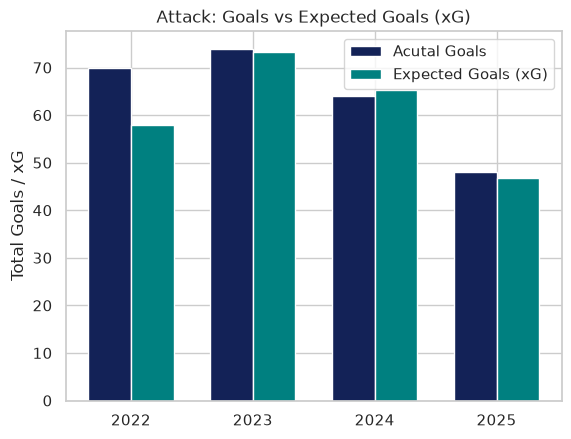

In [181]:
seasons = season_stats["season"]

x = np.arange(len(seasons))
width = 0.35

# 攻撃面（総得点　vs xG）
plt.bar(x - width/2, goals, width, label="Acutal Goals", color='#132257')
plt.bar(x + width/2, xg, width, label="Expected Goals (xG)", color='#008080')
plt.ylabel("Total Goals / xG")
plt.title("Attack: Goals vs Expected Goals (xG)")

plt.xticks(x, seasons)
plt.legend()
plt.show()

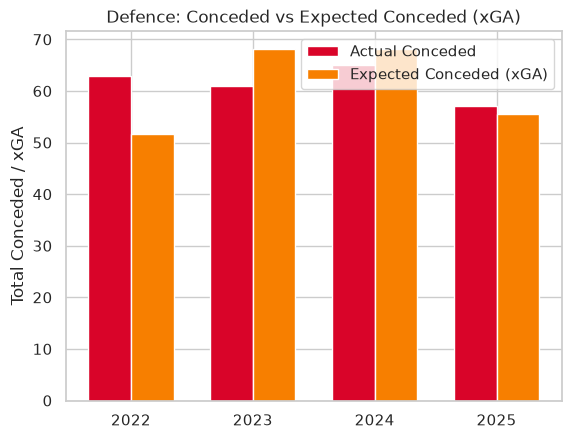

In [182]:
# 守備面（総失点　vs xGA）
plt.bar(x - width/2, conceded, width, label="Actual Conceded", color='#D90429')
plt.bar(x + width/2, xga, width, label="Expected Conceded (xGA)", color='#F77F00')
plt.ylabel("Total Conceded / xGA")
plt.title("Defence: Conceded vs Expected Conceded (xGA)")

plt.xticks(x, seasons)
plt.legend()
plt.show()

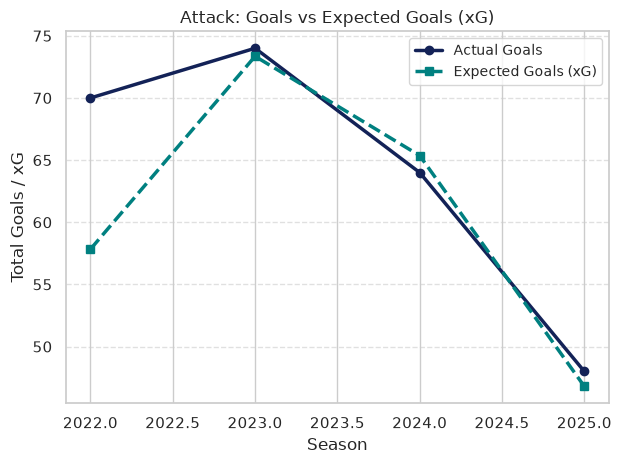

In [196]:
# 攻撃面（総得点　vs xG）　折れ線グラフ
plt.plot(seasons, goals, marker="o", linewidth=2.5, label="Actual Goals", color='#132257')
plt.plot(seasons, xg, marker="s", linewidth=2.5, label="Expected Goals (xG)", color='#008080', linestyle="--")
plt.xlabel("Season")
plt.ylabel("Total Goals / xG")
plt.title("Attack: Goals vs Expected Goals (xG)")

plt.legend(fontsize=10, loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.6)


plt.tight_layout()
plt.show()

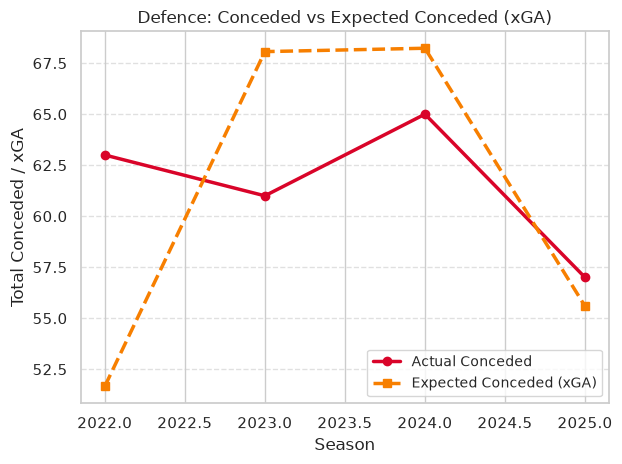

In [201]:
# 守備面（総失点　vs xGA）折れ線グラフ
plt.plot(seasons, conceded, marker="o", linewidth=2.5, label="Actual Conceded", color='#D90429')
plt.plot(seasons, xga, marker="s", linewidth=2.5, label="Expected Conceded (xGA)", color='#F77F00', linestyle="--")
plt.xlabel("Season")
plt.ylabel("Total Conceded / xGA")
plt.title("Defence: Conceded vs Expected Conceded (xGA)")
plt.legend(fontsize=10, loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()